# **PROBLEM 1 (LINEAR REGRESSION)**

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt

# **Unpacking the Dataset**

In [ ]:
df = load_diabetes(as_frame=True)
features = df['data']
target = df['target']
features

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [ ]:
print(features.shape)
print(target.shape)

(442, 10)
(442,)


# **The Dataset Contains 442 Samples or observation and 10 features**

In [ ]:
features.isna().any()

,0
age,False
sex,False
bmi,False
bp,False
s1,False
s2,False
s3,False
s4,False
s5,False
s6,False


# The dataset does not contain any Null Values

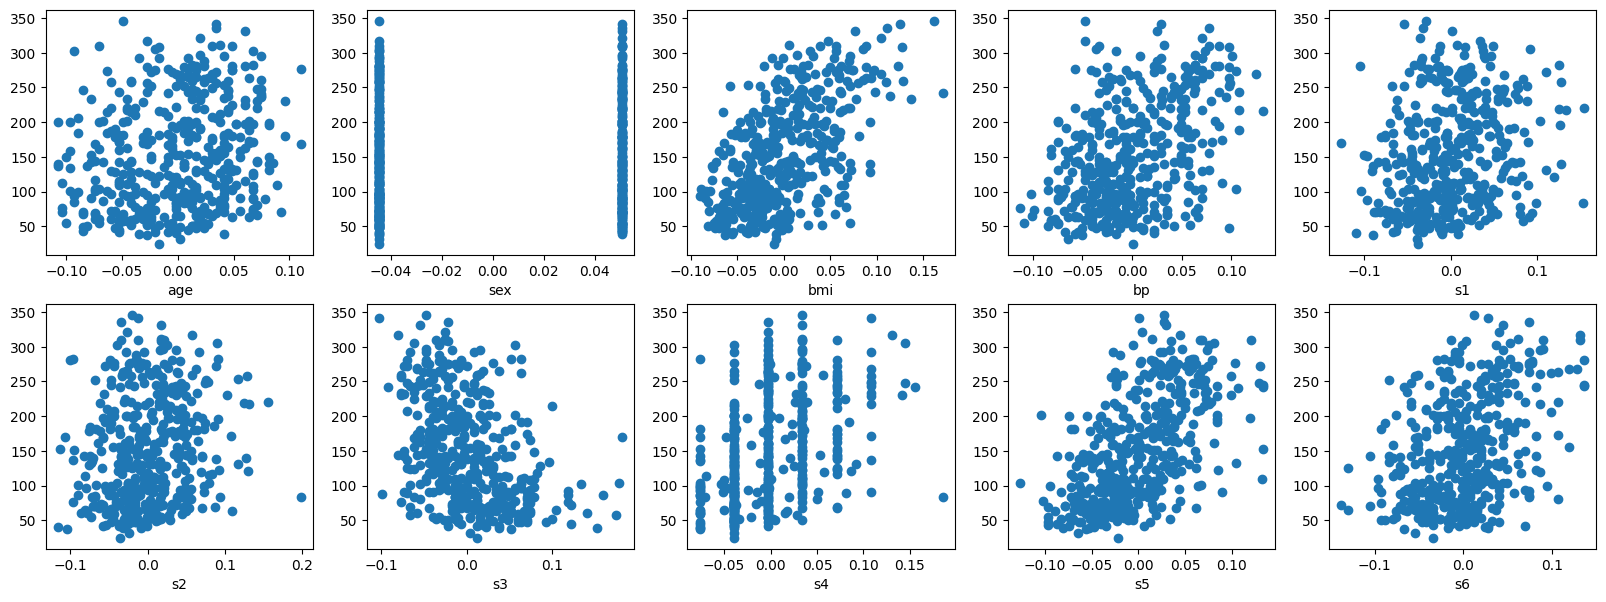

In [ ]:
data = np.array(features)
plt.figure(figsize=(20,7))
for i in range(features.shape[1]):
  plt.subplot(2,5,i+1)
  plt.scatter(data[:,i],target)
  plt.xlabel(features.columns[i])


# Only the feature s1,s2 and s3,s4 Strongly correlate with each other

In [ ]:
features.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


# **Splitting the dataset into Training(75%) and Validation set(25%)**

In [ ]:
training_shape = (round(features.shape[0]*.75),features.shape[1])
trainingX , trainingY = data[0:training_shape[0],:] , target[0:training_shape[0]]
validationX , validationY = data[training_shape[0]:,:] , target[training_shape[0]:]
print(trainingX.shape , validationX.shape)

(332, 10) (110, 10)


# Using the formula : $ \hat{β} = (X^TX)^{-1} X^T Y $ where X is augmented feature matrix with the bias column an Y is target column

In [ ]:
def OLS(x,y):
  X = np.column_stack(([1 for i in range(x.shape[0])],x))
  beta  = np.dot(np.linalg.inv(np.dot(X.T,X)) , np.dot(X.T,y))
  return beta
OLS(trainingX , trainingY)

array([ 151.73840413,    2.0955722 , -234.76245188,  503.77860105,
        292.80152807, -482.65336108,  212.27012031,  -26.67452296,
        138.83098223,  652.17744593,   99.50193875])

# Performing Validation on the Validation Set using the equation $Y = Xβ$

In [ ]:
def prediction(coef,testX):
 test = np.column_stack(([1 for i in range(testX.shape[0])],testX))
 pred = np.dot(test,coef)
 return pred

prediction(OLS(trainingX , trainingY),validationX).size

110

# Calculating the Mean squared Error
$\frac{1}{n}∑({\hat{y}-y})^2$ and $R^2 = 1 - \frac{RSS}{TSS}$ where RSS is Residual Sum of square = $∑(\hat{y}-y)^2$ and TSS is total Sum of Squares = $\sum({<y> - y})^2$

In [ ]:
def error(ytrue , ypredicted):
  mse = np.mean((ytrue - ypredicted)**2)
  rss = np.sum((ypredicted - ytrue)**2)
  tss = np.sum((ytrue - np.mean(ytrue))**2)
  r_square = 1 - (rss/tss)
  return mse , r_square

In [ ]:
print(f"The Mean squared Error is {error(validationY,prediction(OLS(trainingX , trainingY),validationX))[0]} and the R-Squared Value is {error(validationY,prediction(OLS(trainingX , trainingY),validationX))[1]}")

The Mean squared Error is 2732.3884212594708 and the R-Squared Value is 0.5575557705003225


In [ ]:
def error_plot(ytrue,ypredicted):
  x = np.arange(0,ytrue.size)
  plt.figure(figsize=(15,5))
  plt.plot(x,ytrue,label = "Truth")
  plt.plot(x,ypredicted,label = "Prediction")
  plt.legend

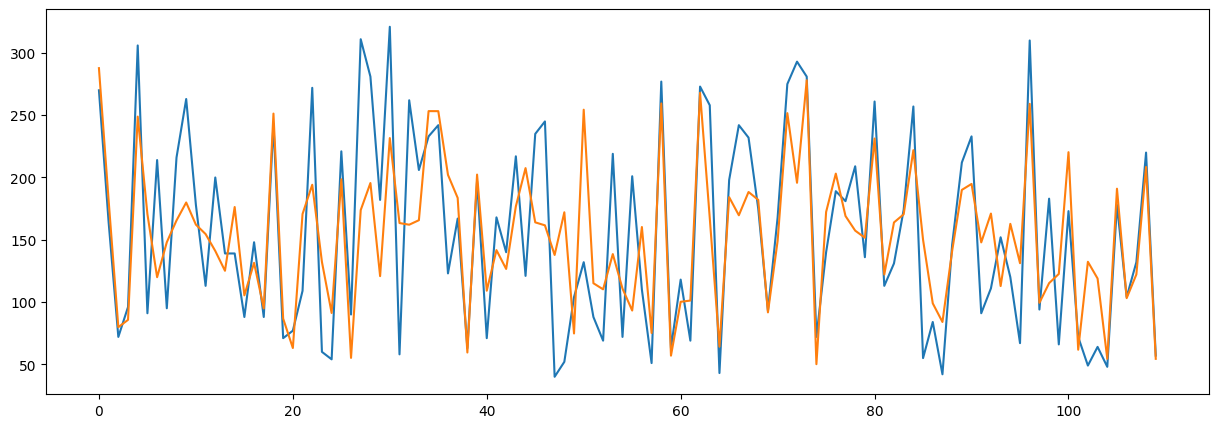

In [ ]:
error_plot(validationY,prediction(OLS(trainingX , trainingY),validationX))

# Using Scikit-Learn Library

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
model = LinearRegression(fit_intercept=True)
model.fit(trainingX,trainingY)
model.score(validationX,validationY)

0.5575557705003222

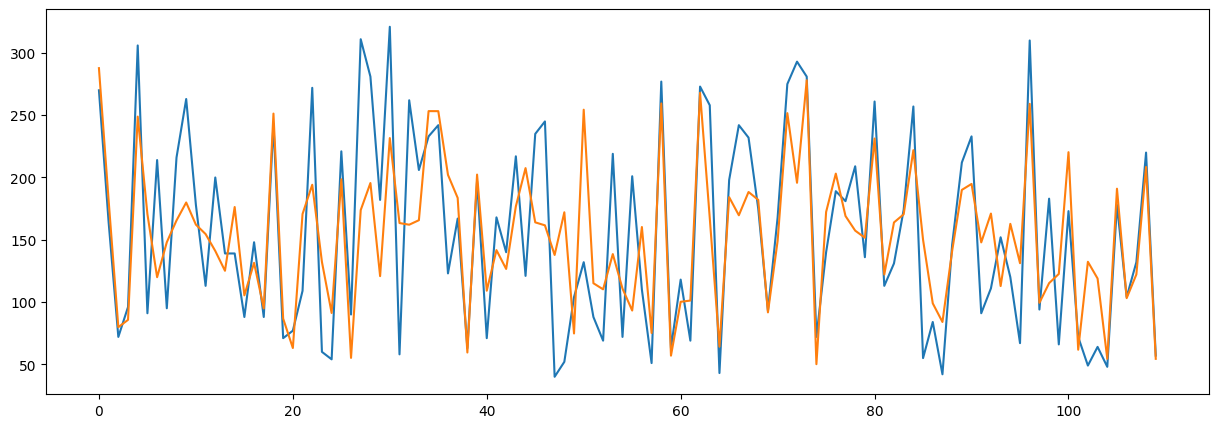

In [ ]:
error_plot(validationY,model.predict(validationX))

# We observe that the performance metrics for my model exactly match with Scikit-learn's Linear regression model with respect to Validation dataset

# We will now apply Forward Stepwise Selection to build the best design matrix and evaluate it using Adjusted R Square $\bar{R}^2 = 1 - (1 - R^2) \frac{n - 1}{n - p - 1}$ , where p is no. of columns added so far and n is total observations

In [ ]:
design = np.empty((trainingX.shape[0],0))
max_rsquare = 0
col_added = []
for i in range(features.columns.size):
  adjusted_rsquare = {}
  for j in range(features.columns.size):
    if j not in col_added:
      if design.size == 0 :
        beta = OLS(trainingX[:,j],trainingY)
        pred = prediction(beta,validationX[:,j])
      else:
        beta = OLS(np.column_stack((design,trainingX[:,j])),trainingY)
        pred = prediction(beta , np.column_stack((validationX[:,col_added],validationX[:,j])))
      adjusted_rsquare[j] = 1 - (((1-error(validationY,pred)[1])*(validationY.size - 1))/(validationY.size - (len(col_added)+1) - 1))
  if max(adjusted_rsquare.values()) > max_rsquare:
    max_rsquare = max(adjusted_rsquare.values())
    print(adjusted_rsquare)
    print(max_rsquare)
    col_added.append(max(adjusted_rsquare,key = adjusted_rsquare.get))
    design = np.column_stack((design,trainingX[:,max(adjusted_rsquare,key = adjusted_rsquare.get)]))
    print(col_added)
  else:
    break



{0: np.float64(0.025522118518848447), 1: np.float64(-0.008109212502511953), 2: np.float64(0.39772986371298225), 3: np.float64(0.22944414230795807), 4: np.float64(0.01964252786957077), 5: np.float64(0.011217657256293978), 6: np.float64(0.16642499431007718), 7: np.float64(0.15007829910300008), 8: np.float64(0.2639201496186018), 9: np.float64(0.12343257702268517)}
0.39772986371298225
[2]
{0: np.float64(0.4011387561281027), 1: np.float64(0.3911508865990485), 3: np.float64(0.45424184783993526), 4: np.float64(0.3979297794490534), 5: np.float64(0.393138725334118), 6: np.float64(0.431419577500908), 7: np.float64(0.42975009821395604), 8: np.float64(0.4702709075292033), 9: np.float64(0.3992946434261774)}
0.4702709075292033
[2, 8]
{0: np.float64(0.46524082451406035), 1: np.float64(0.46870342952917343), 3: np.float64(0.503679235007513), 4: np.float64(0.4779080811379691), 5: np.float64(0.4681494461002792), 6: np.float64(0.4780666382126315), 7: np.float64(0.46590825660961366), 9: np.float64(0.466443

In [ ]:
print(f"The best features selected are {features.columns[col_added]}")

The best features selected are Index(['bmi', 's5', 'bp', 's3', 'sex'], dtype='object')


We can observe the Adjusted R sqyare Value came out to be lower than R Square which means , R Square Value calculated during Ordinary Least Square captured the noise(overfit) but Adjusted R square solely relied on the predicitive capacity of the features  .

# Backward Stepwise Selection

In [ ]:
def func(li):
  b = []
  c = []
  for i in li:
    a = []
    for j in li :
      if j!=i:
        a.append(j)
    b.append(a)
    c.append(i)
  return b,c

#This function calculates and return all possible subsets of the list of columns

In [ ]:
flag = True
for i in range(features.columns.size):
  rsquare_adj = {}
  c = 0
  if i == 0:
    beta = OLS(trainingX,trainingY)
    pred = prediction(beta , validationX)
    adjusted_rsquare = 1 - (((1-error(validationY,pred)[1])*(validationY.size - 1))/(validationY.size - (features.columns.size-i) - 1))
  else :
    if flag:
      columns = func([i for i in range(features.columns.size)])
    else:
      columns = func(cols)
    for  j in columns[0]:
      beta = OLS(trainingX[:,j],trainingY)
      pred = prediction(beta , validationX[:,j])
      rsquare_adj[columns[1][c]] = 1 - (((1-error(validationY,pred)[1])*(validationY.size - 1))/(validationY.size - (features.columns.size-i) - 1))
      c += 1
    if max(rsquare_adj.values()) > adjusted_rsquare:
      print(rsquare_adj)
      adjusted_rsquare = max(rsquare_adj.values())          # This code doesn't handle the case when dropping two different features give same Adjusted R-Sq
      cols = [i for i in rsquare_adj.keys() if rsquare_adj[i] != max(rsquare_adj.values()) ]
      print(cols)
      flag = False
    else:
      break

{0: np.float64(0.5177995534662031), 1: np.float64(0.4973435658385418), 2: np.float64(0.4217154221526762), 3: np.float64(0.4699143833453724), 4: np.float64(0.5075111312750126), 5: np.float64(0.5124996956122947), 6: np.float64(0.5184352206643685), 7: np.float64(0.5147084732333431), 8: np.float64(0.4775315711334335), 9: np.float64(0.5213655857179276)}
[0, 1, 2, 3, 4, 5, 6, 7, 8]
{0: np.float64(0.5264697250021184), 1: np.float64(0.5037868021719635), 2: np.float64(0.4233454476972831), 3: np.float64(0.47516775625730623), 4: np.float64(0.5158587162773771), 5: np.float64(0.5207540682519303), 6: np.float64(0.5265710876863632), 7: np.float64(0.5230320491245162), 8: np.float64(0.4861688137249227)}
[0, 1, 2, 3, 4, 5, 7, 8]
{0: np.float64(0.5315508298331544), 1: np.float64(0.5075176441243534), 2: np.float64(0.429858198901385), 3: np.float64(0.48105799787346637), 4: np.float64(0.5129333041396242), 5: np.float64(0.5246059823628443), 7: np.float64(0.5331779730883363), 8: np.float64(0.4902907688811321)

In [ ]:
print(f"The features that best work together are {features.columns[cols]}")

The features that best work together are Index(['sex', 'bmi', 'bp', 's1', 's2', 's5'], dtype='object')


# Applying Ridge(L2) Regression to this using the formula :
# $$\hat{\beta} = (X^T X + \lambda I)^{-1} X^T Y$$


In [ ]:
I = np.zeros((trainingX.shape[1]+1,trainingX.shape[1]+1))
for i in range(1,I.shape[0]):
  for j in range(1,I.shape[0]):
    if i==j:
      I[i][j] = 1
I
#We use a modified Identity Matrix to prevent regularization of bias

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [ ]:
lmd = [.01, .1, 1, 10, 100]
X = np.column_stack(([1 for i in range(trainingX.shape[0])],trainingX))
for i in lmd :
  beta = np.dot(np.linalg.inv(np.dot(X.T,X) + i * I),np.dot(X.T,trainingY))
  pred = prediction(beta,validationX)
  err = error(validationY,pred)
  print(err[0],err[1])

2765.418163173059 0.5522074025311761
2815.8129975563265 0.544047177763721
3423.901592541943 0.4455819347614328
5225.992339363926 0.15377691693800388
6060.254692116656 0.01868830325762183


# We can observe as Lambda increases ,penalty increases and as a result , Mean squared error inceases and hence R square decreases

In [ ]:
from sklearn.linear_model import Ridge
for i in lmd:
  model = Ridge(i)
  model.fit(trainingX,trainingY)
  print(model.score(validationX,validationY))

0.5522074025311764
0.544047177763721
0.44558193476143293
0.15377691693800377
0.018688303257621608


# Implementing Lasso(L1) Rgressio using Sklearn

In [ ]:
from sklearn.linear_model import Lasso
for i in lmd:
  model = Lasso(i)
  model.fit(trainingX,trainingY)
  print(model.score(validationX,validationY))                # In lasso , we use modulus of weights which isn't differentiable hence I use Sklearn

0.5525071402877706
0.5438020354257782
0.3642008254571064
-0.002240121328026312
-0.002240121328026312


# We can see the R Square value decreased rapidly which means it quickly reduced the weights to 0

# **PROBLEM 2 (Logistic Regression)**

# Setting up the Problem

This is a multi- class Classification , hence Binary Classification won't work and we need a Softmax function ( not Binary Cross Entropy) . Loss function must be Categorical Cross Entropy . Finally , the relevant formulas and how they are derived are listed below :

1. The Forward Pass $$Z = XW^T $$where W = (C x m+1) and C -classes , m-features $$P = \text{softmax}(Z) = \frac{e^{Z_{i,j} - \max(Z_i)}}{\sum e^{Z_{i,j} - \max(Z_i)}}$$
2. The Loss (Categorical Cross-Entropy) : $$L = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} Y_{ik} \log(P_{ik})$$
We want to find $\frac{\partial L}{\partial W}$.
We know that $L$ depends on the scores $Z$, and $Z$ depends on the weights $W$ ($Z = XW$).The Chain Rule tells us:$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$
Using the Chain Rule, we need to find how the loss changes with respect to the probability, and how the probability changes with respect to the logit:$$\frac{\partial L}{\partial z_k} = \sum_{j} \frac{\partial L}{\partial p_j} \frac{\partial p_j}{\partial z_k}$$
Step A: Derivative of Loss w.r.t. Probability ($\frac{\partial L}{\partial p_j}$)
$$\frac{\partial L}{\partial p_j} = -\frac{y_j}{p_j}$$
Step B: Derivative of Softmax w.r.t. Logits ($\frac{\partial p_j}{\partial z_k}$)


  >> Case 1: Derivative ($j = k$)

$$\frac{\partial p_k}{\partial z_k} = \frac{(e^{z_k})(\sum e^{z_i}) - (e^{z_k})(e^{z_k})}{(\sum e^{z_i})^2}$$

>$$\frac{\partial p_k}{\partial z_k} = \frac{e^{z_k}}{\sum e^{z_i}} \cdot \frac{\sum e^{z_i} - e^{z_k}}{\sum e^{z_i}}$$
>>$$\frac{\partial p_k}{\partial z_k} = p_k \cdot (1 - p_k)$$
Case 2: The "Interaction" Derivative ($j \neq k$)
<br>
$$\frac{\partial p_j}{\partial z_k} = \frac{(0)(\sum e^{z_i}) - (e^{z_j})(e^{z_k})}{(\sum e^{z_i})^2}$$
>$$\frac{\partial p_j}{\partial z_k} = \frac{- e^{z_j} \cdot e^{z_k}}{(\sum e^{z_i})^2}$$
$$\frac{\partial p_j}{\partial z_k} = - \left( \frac{e^{z_j}}{\sum e^{z_i}} \right) \cdot \left( \frac{e^{z_k}}{\sum e^{z_i}} \right)$$$$\frac{\partial p_j}{\partial z_k} = - p_j p_k$$
plug those back into our Chain Rule equation :$$\frac{\partial L}{\partial z_k} = \left( \frac{\partial L}{\partial p_k} \cdot \frac{\partial p_k}{\partial z_k} \right) + \sum_{j \neq k} \left( \frac{\partial L}{\partial p_j} \cdot \frac{\partial p_j}{\partial z_k} \right)$$Substituting:$$\frac{\partial L}{\partial z_k} = \left( -\frac{y_k}{p_k} \cdot p_k(1 - p_k) \right) + \sum_{j \neq k} \left( -\frac{y_j}{p_j} \cdot (-p_j p_k) \right)$$Now, watch the terms cancel out:$$\frac{\partial L}{\partial z_k} = -y_k(1 - p_k) + \sum_{j \neq k} y_j p_k$$$$\frac{\partial L}{\partial z_k} = -y_k + y_k p_k + \sum_{j \neq k} y_j p_k$$Factor out $p_k$:$$\frac{\partial L}{\partial z_k} = -y_k + p_k \left( y_k + \sum_{j \neq k} y_j \right)$$

In Matrix Form:$$\frac{\partial L}{\partial Z} = P - Y$$ where P has dimension(N x C) , N - samples.<br>
We look at the linear equation: $Z = XW$.If we take the derivative of $Z$ with respect to $W$:$$\frac{d}{dW}(XW) = X$$

The resulting matrix must have the shape of $W$ (which is $Features \times Classes$).Shape of $X$: $(m \times n)$ where $m$ is samples and $n$ is features.Shape of $(P - Y)$: $(m \times K)$ where $m$ is samples and $K$ is classes.To get a matrix of shape $(n \times K)$:
$$\frac{\partial L}{\partial W} = (P - Y)^TX$$ so basically (C x N) * (N x m+1) = (C x m+1)

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = load_iris(as_frame=True)
features = df['data']
target = df['target']
target_names = df.target_names
features.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
print(features.isnull().any())
print(target.isnull().any())

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
dtype: bool
False


# We can see from here that the classes are fairly Balanced

In [ ]:
target.value_counts()

,count
target,
0,50
1,50
2,50


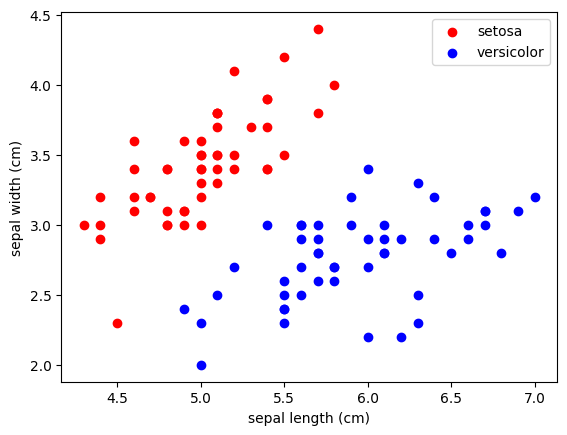

In [ ]:
# Plotting some features ti show the difference in features
plt.scatter(features[target == 0].iloc[:,0] , features[target == 0].iloc[:,1] , color='red',label = target_names[0])
plt.scatter(features[target == 1].iloc[:,0] , features[target == 1].iloc[:,1] , color='blue',label = target_names[1])
plt.xlabel(features.columns[0])
plt.ylabel(features.columns[1])
plt.legend()

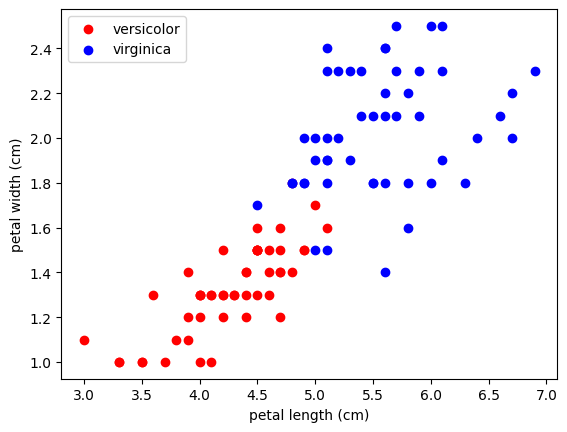

In [ ]:
plt.scatter(features[target == 1].iloc[:,2] , features[target == 1].iloc[:,3] , color='red',label = target_names[1])
plt.scatter(features[target == 2].iloc[:,2] , features[target == 2].iloc[:,3] , color='blue',label = target_names[2])
plt.xlabel(features.columns[2])
plt.ylabel(features.columns[3])
plt.legend()

# Implementing Logistic Regression

**Manually encoding the labels**

In [ ]:
for i in range(target.shape[0]):
  if target[i] == 0:
    features.loc[i,target_names[0]] = 1
    features.loc[i,target_names[1]] = 0
    features.loc[i,target_names[2]] = 0
  elif target[i] == 1:
    features.loc[i,target_names[0]] = 0
    features.loc[i,target_names[1]] = 1
    features.loc[i,target_names[2]] = 0
  else:
    features.loc[i,target_names[0]] = 0
    features.loc[i,target_names[1]] = 0
    features.loc[i,target_names[2]] = 1

features.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,1.0,0.0,0.0
1,4.9,3.0,1.4,0.2,1.0,0.0,0.0
2,4.7,3.2,1.3,0.2,1.0,0.0,0.0
3,4.6,3.1,1.5,0.2,1.0,0.0,0.0
4,5.0,3.6,1.4,0.2,1.0,0.0,0.0


In [ ]:
def categorical_cross_entropy(prediction):
  s = 0.0
  ep = 1e-15
  for i in range(len(prediction)):
    if prediction[i] == 1:
      s = s - 1.0 * np.log(prediction[i] - ep)  # If prob is 1 , we are doing 1 - very small value , so that it does not become 0
    elif prediction[i] == 0:
      s = s - 1.0 * np.log(prediction[i] + ep)  # # If prob is 0 , we are doing 0 + very small value , so that it does not become 0
    else:
      s = s  - 1.0 * np.log(prediction[i])

  return s/len(prediction)

In [ ]:
def softmax(distance):
  p = np.empty(distance.shape)
  if distance.ndim == 2:
    for i in range(p.shape[0]):
      for j in range(p.shape[1]):
        p[i,j] = np.exp(distance[i,j] - distance[i].max()) / np.sum(np.exp(distance[i] - distance[i].max()))
  else:
    for i in range(p.shape[0]):
      p[i] = np.exp(distance[i] - distance.max()) / np.sum(np.exp(distance - distance.max()))
  return p

In [ ]:
def find_prob_true_class(true,p):       #  Return a vector of probabilities corresponding to true class for all samples
  probability = []
  for i in range(true.shape[0]):
    for j in range(true.shape[1]):
      if true[i,j] == 1:
        probability.append(p[i,j])
  return probability

In [ ]:
def accuracy(true , prob):
  c = 0.0
  for i in range(true.shape[0]):
    if np.argmax(true[i]) == np.argmax(prob[i]):
      c += 1
  return c/true.shape[0]

In [ ]:
def gradient_descent(X , Y , weight ,epoch,threshold,rate):
  loss = []
  #Augmenting the training data with ones to incorporate bias
  X = np.column_stack(([1 for i in range(X.shape[0])],X))
  for i in range(epoch):
    z = np.dot(X,weight.T)
    prob = softmax(z)
    true_prob = find_prob_true_class(Y , prob)   # returns the probability corresponding to the True class
    loss.append(categorical_cross_entropy(true_prob))
    weight = weight - rate * (1/X.shape[0])*np.dot((prob-Y).T,X)
    print(f"Epoch {i+1} Loss {loss[i]} Accuracy {accuracy(Y , prob)}")
    if loss[i]<threshold:
      break
  return weight

In [ ]:
def initializer(features,classes):
  weights = np.random.randn(classes.size,features.iloc[:,:-3].shape[1])*0.01   # Initializing weights with with small random values
  bias = np.zeros(classes.size)
  weight_aug = np.column_stack((bias,weights))
  return weight_aug

# Splitting the dataset into training and testing (75% and 25 %)

But we have to do so in such a way that both training and testing has equal amount of all classes , otherwise model can become biased

In [ ]:
def train_test(features,target_names):
  data = features[[features.columns[i] for i in range(4)]]
  trainX = np.empty((round(features.shape[0]*.25)*target_names.size,data.shape[1]))
  testX = np.empty((round(features.shape[0]*.08)*target_names.size,data.shape[1]))
  trainY = np.empty((round(features.shape[0]*.25)*target_names.size,target_names.size))
  testY = np.empty((round(features.shape[0]*.08)*target_names.size,target_names.size))
  trainX[0:38,:] = data.iloc[0:38,:]
  trainX[38:76,:] = data.iloc[50:88,:]
  trainX[76:114,:] = data.iloc[100:138,:]
  testX[0:12] = data.iloc[38:50,:]
  testX[12:24] = data.iloc[88:100,:]
  testX[24:36] = data.iloc[138:150,:]
  trainY[0:38,:] = features.iloc[0:38,-3:]
  trainY[38:76,:] = features.iloc[50:88,-3:]
  trainY[76:114,:] = features.iloc[100:138,-3:]
  testY[0:12] = features.iloc[38:50,-3:]
  testY[12:24] = features.iloc[88:100,-3:]
  testY[24:36] = features.iloc[138:150,-3:]
  return trainX , testX , trainY , testY

In [ ]:
xtrain,xtest , ytrain , ytest = train_test(features , target_names )

In [ ]:
weight = gradient_descent(xtrain,ytrain,initializer(features,target_names),500,0.01,0.1)


Epoch 1 Loss 1.0973784542036376 Accuracy 0.3333333333333333
Epoch 2 Loss 1.0268733701322514 Accuracy 0.3333333333333333
Epoch 3 Loss 0.9630047213254496 Accuracy 0.6666666666666666
Epoch 4 Loss 0.9118578175380523 Accuracy 0.6666666666666666
Epoch 5 Loss 0.8695567981167773 Accuracy 0.6929824561403509
Epoch 6 Loss 0.8362055603519866 Accuracy 0.6666666666666666
Epoch 7 Loss 0.8137359552167979 Accuracy 0.6666666666666666
Epoch 8 Loss 0.8042315471436501 Accuracy 0.6666666666666666
Epoch 9 Loss 0.8071728135588172 Accuracy 0.6666666666666666
Epoch 10 Loss 0.8332081340017075 Accuracy 0.6666666666666666
Epoch 11 Loss 0.8388499478299521 Accuracy 0.6666666666666666
Epoch 12 Loss 0.8768264665495037 Accuracy 0.6666666666666666
Epoch 13 Loss 0.8344489720765079 Accuracy 0.6666666666666666
Epoch 14 Loss 0.8663171164777388 Accuracy 0.6666666666666666
Epoch 15 Loss 0.8062080748352735 Accuracy 0.6666666666666666
Epoch 16 Loss 0.8437536351173318 Accuracy 0.6666666666666666
Epoch 17 Loss 0.780779490339091 A

In [ ]:
def prediction(x,y,w):
  x = np.column_stack(([1 for i in range(x.shape[0])],x))
  z = np.dot(x,w.T)
  p = softmax(z)
  true_p = find_prob_true_class(y,p)
  loss = categorical_cross_entropy(true_p)
  acc = accuracy(y,p)
  print(f" Loss: {loss} Accuracy {acc}")
  a = []
  for i in range(p.shape[0]):
    a.append(np.argmax(p[i,:]))
  return a

In [ ]:
a = prediction(xtest,ytest,weight)
pred = [target_names[i] for i in a]
print(pred)
true = []
for i in range(ytest.shape[0]):
  true.append(target_names[np.argmax(ytest[i,:])])
print(true)

 Loss: 0.1743942085244068 Accuracy 1.0
[np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica')]
[np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), n

In [ ]:
from sklearn.linear_model import LogisticRegression
xtrain,xtest , ytrain , ytest = train_test(features , target_names )
model = LogisticRegression(solver = 'saga',max_iter = 1700)
model.fit(xtrain,np.argmax(ytrain,axis=1))
print(f"Accuracy : {model.score(xtest,np.argmax(ytest,axis=1))} Loss : {categorical_cross_entropy(find_prob_true_class(ytest,model.predict_proba(xtest)))}")
print([target_names[i] for i in model.predict(xtest)])
true = []
for i in range(ytest.shape[0]):
  true.append(target_names[np.argmax(ytest[i,:])])
print(true)



Accuracy : 1.0 Loss : 0.12897136979144805
[np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica')]
[np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa')

# Implementing 3 Fold Cross validation for Both Sklearn's Model and my Model

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score,recall_score
import pandas as pd
accu , recall , precision = [],[],[]
k = StratifiedKFold(n_splits=3,shuffle=True)
for train_idx , test_idx in k.split(features.iloc[:,:-3],target):
  weight = gradient_descent(features.iloc[train_idx,:-3].to_numpy(),pd.get_dummies(target[train_idx]).to_numpy(),initializer(features,target_names),500,0.01,0.1)
  b = prediction(features.iloc[test_idx,:-3].to_numpy(),pd.get_dummies(target[test_idx]).to_numpy(),weight)
  accu.append(accuracy_score(target[test_idx],b))
  precision.append(precision_score(target[test_idx],b,average='macro'))
  recall.append(recall_score(target[test_idx],b,average='macro'))
print(f"Average accuracy: {np.mean(accu)},Average Recall : {np.mean(recall)},Average Precision : {np.mean(precision)}")

Epoch 1 Loss 1.0897339208170862 Accuracy 0.34
Epoch 2 Loss 1.0247559748989117 Accuracy 0.34
Epoch 3 Loss 0.9686645913210815 Accuracy 0.91
Epoch 4 Loss 0.9231176216684165 Accuracy 0.66
Epoch 5 Loss 0.8887204542173051 Accuracy 0.66
Epoch 6 Loss 0.8639518851272596 Accuracy 0.67
Epoch 7 Loss 0.8508273343440501 Accuracy 0.66
Epoch 8 Loss 0.8514685869750559 Accuracy 0.67
Epoch 9 Loss 0.8481310721342747 Accuracy 0.66
Epoch 10 Loss 0.8658080599971221 Accuracy 0.67
Epoch 11 Loss 0.839790195973827 Accuracy 0.66
Epoch 12 Loss 0.8592257122022162 Accuracy 0.67
Epoch 13 Loss 0.811103305133768 Accuracy 0.66
Epoch 14 Loss 0.835045219608237 Accuracy 0.67
Epoch 15 Loss 0.7806694623598485 Accuracy 0.66
Epoch 16 Loss 0.8114376166139813 Accuracy 0.67
Epoch 17 Loss 0.754510981372417 Accuracy 0.66
Epoch 18 Loss 0.7908674205131707 Accuracy 0.67
Epoch 19 Loss 0.7323265302967422 Accuracy 0.66
Epoch 20 Loss 0.7729331369366327 Accuracy 0.67
Epoch 21 Loss 0.7131979526868311 Accuracy 0.66
Epoch 22 Loss 0.7570427711

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,precision_score,recall_score
import pandas as pd
accu , recall , precision = [],[],[]
for train_idx , test_idx in k.split(features.iloc[:,:-3],target):
  model = LogisticRegression(solver='saga',max_iter = 1900)
  model.fit(features.iloc[train_idx,:-3],target[train_idx])
  accu.append(accuracy_score(target[test_idx],np.argmax(model.predict_proba(features.iloc[test_idx,:-3]),axis=1)))
  precision.append(precision_score(target[test_idx],np.argmax(model.predict_proba(features.iloc[test_idx,:-3]),axis=1),average='macro'))
  recall.append(recall_score(target[test_idx],np.argmax(model.predict_proba(features.iloc[test_idx,:-3]),axis=1),average='macro'))
print(f"Mean accuracy : {np.mean(accu)},mean Recall : {np.mean(recall)}, Mean Precision : {np.mean(precision)}")

Mean accuracy : 0.9733333333333333,mean Recall : 0.9734477124183006, Mean Precision : 0.9755953063486603


#**PROBLEM 3 (Decision Tree Classifier)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

In [ ]:
df = load_digits(as_frame = True)  # This df contains data , target , frame, images(2 x 2) , target_names , feature_names in dictionary format
data = df['frame']
target = df['target']
data.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


# Plotting some Images of Handwritten Digits

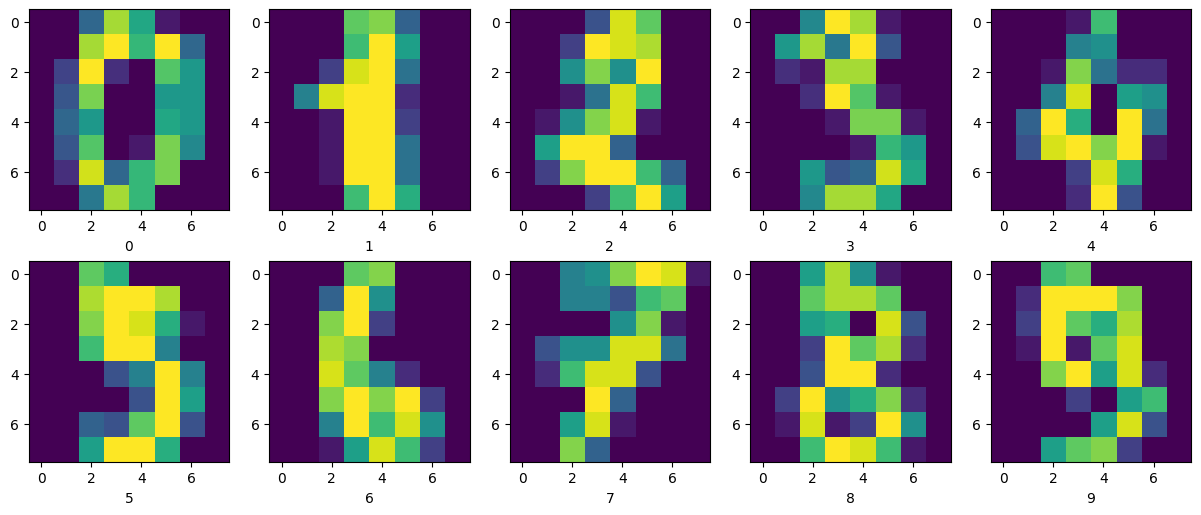

In [ ]:
plt.figure(figsize = (15,6))
for i in range(10):
  plt.subplot(2,5,(i+1))
  # plt.imshow(data.iloc[i,:].to_numpy().reshape(8,8))
  plt.imshow(df['images'][i])
  plt.xlabel(target[i])

Mathematical framework behind the Decision Tree Approach to be implemented here:

Technical Specification: The CART Algorithm
The Classification and Regression Tree (CART) approach is a recursive partitioning method used to construct a binary decision tree by minimizing impurity at each node.

1. Root Node Initialization : Let $\mathcal{D}$ represent the set of training observations at the current node. The algorithm initiates at the Root, where $\mathcal{D}$ contains the entire training dataset.
2. Objective Function: The Optimal Split Search <br>
To determine the optimal partition, the algorithm performs an exhaustive search across all features $j$ and all possible threshold values $t$. For a given feature-threshold pair $(j, t)$, the data is partitioned into two subsets:


*   Left Branch ($L$): $\{x \in \mathcal{D} \mid x_j \le t\}$
*   Right Branch ($R$): $\{x \in \mathcal{D} \mid x_j > t\}$
The quality of the split is evaluated using the Weighted Gini Impurity $G(\mathcal{D}, j, t)$:
$$G(\mathcal{D}, j, t) = \frac{n_L}{n} \text{Gini}(\mathcal{D}_L) + \frac{n_R}{n} \text{Gini}(\mathcal{D}_R)$$
Where the Gini Impurity for any node $m$ is defined as:

$$\text{Gini}(m) = 1 - \sum_{i=1}^{K} p_{mi}^2$$



#I will use GINI Gain to build my Decision Tree

In [ ]:
def gini(dataframe):
    prob = 0
    for i in dataframe['target'].value_counts().values:
        prob = prob + (i/np.sum(dataframe['target'].value_counts().values))**2
    return (1-prob)

In [ ]:
def split(n,a):
    dict = {}
    for i in n :
        gini_L = gini(a[a.iloc[:,0]<= i])
        size_L =  a[a.iloc[:,0]<= i].shape[0]
        gini_R = gini(a[a.iloc[:,0] > i])
        size_R =  a[a.iloc[:,0] > i].shape[0]
        dict[i] = (size_L/a.shape[0])*gini_L + (size_R/a.shape[0])*gini_R
    return dict

In [ ]:
def gain(impure,d,b):
    actual = gini(d)
    info_gain = []
    for i in impure.values():
        info_gain.append(actual - i)
    return (np.max(info_gain),b[np.argmax(info_gain)])     # Returning the maximum information Gain and Best split value

In [ ]:
def finding_threshold(col,data):
    a = data[[col,'target']].sort_values(by = col).reset_index(drop = True)
    b = []
    for i in range(1,a.shape[0]):
        if a.iloc[i,1] != a.iloc[i-1,1]:
            b.append((a.iloc[i,0] + a.iloc[i-1,0])/2.0)       # Storing the mid - points of transition points
    b = np.unique(b)    # b can have multiple repeated values but it doesn't matter because splitting considers all of them in single run
    if b.size == 0 :
        return None,None
    split_impurity = split(b,a)
    return gain(split_impurity,data,b)

In [ ]:
def build_model(data,thres_info_gain,depth):
    tree = {}

    best_feature = None
    best_split = 0

    impurity = gini(data)
    info_gain = 0

# The above functions in previous cells basically find for a particular Column , Best Splitting value and Best Information Gain
# Below loop finds the BEST Feature for a given Dataframe across all the features available
    for i in data.columns:
        if i != 'target':
            temp , t = finding_threshold(i,data)
            if temp is None:
                continue            # If a single feature doesn't provide any information , skip it and continue to next iteration
            if temp > info_gain:
                info_gain = temp      # information gain is updated if it's better than information gain of other columns
                best_feature = i
                best_split = t

    if best_feature is None:     #If the loop skipped through all Features for a totally pure(target constant) Dataframe
      return data['target'].mode().values[0]

    print(f"Depth {depth} Best Feature :{best_feature} Information Gain : {round(info_gain,3)} Gini Impurity : {round(impurity,3)}")
    # Setting some Stopping Conditions to stop large number of iterations or Overfitting

    if info_gain < thres_info_gain :
        return data['target'].mode().values[0]
    if impurity == 0:
        return data['target'].mode().values[0]
    tree['Best Feature'] = best_feature
    tree['Threshold'] = best_split
     # Including this Left and Right within the Dictionary (not the recusion calls) was obtained from searches as I couldn't figure it out myself
    tree['left'] = build_model(data[data[best_feature] <= best_split],thres_info_gain,depth + 1)
    tree['right'] = build_model(data[data[best_feature] > best_split],thres_info_gain,depth + 1)

    return tree


In [ ]:
def prediction(tree,sample):
    if isinstance(tree,(np.floating,np.integer)):   # isinstance checks if the data is of a particular data type or not
        return tree
    if sample[tree['Best Feature']] > tree['Threshold']:
        return prediction(tree['right'],sample)
    else:
        return prediction(tree['left'],sample)

In [ ]:
def train_test(data , train_size):
  a = np.array([i for i in range(data.shape[0])])  # An array of row indices or samples
  np.random.shuffle(a)
  train_index = a[0:round(data.shape[0] * train_size)]
  test_index = a[round(data.shape[0] * train_size):]

  # Taking set difference to obtain testing indices

  return data.iloc[train_index,:] , data.iloc[test_index,:-1] , data.iloc[train_index,-1] , data.iloc[test_index,-1]

In [ ]:
Xtrain , Xtest , Ytrain , Ytest = train_test(data , 0.70)
print(Xtrain.shape[0]/data.shape[0])
print(Xtest.shape[0]/data.shape[0])

0.7000556483027268
0.29994435169727324


In [ ]:
model = build_model(Xtrain , thres_info_gain = 0.01 , depth = 0 )

Depth 0 Best Feature :pixel_5_2 Information Gain : 0.485 Gini Impurity : 0.9
Depth 1 Best Feature :pixel_5_3 Information Gain : 0.462 Gini Impurity : 0.851
Depth 2 Best Feature :pixel_3_2 Information Gain : 0.533 Gini Impurity : 0.74
Depth 3 Best Feature :pixel_3_6 Information Gain : 0.488 Gini Impurity : 0.435
Depth 4 Best Feature :pixel_7_7 Information Gain : 0.358 Gini Impurity : 0.207
Depth 5 Best Feature :pixel_0_4 Information Gain : 0.148 Gini Impurity : 0.067
Depth 6 Best Feature :pixel_2_2 Information Gain : 1.0 Gini Impurity : 0.5
Depth 5 Best Feature :pixel_0_2 Information Gain : 0.971 Gini Impurity : 0.64
Depth 6 Best Feature :pixel_0_4 Information Gain : 0.918 Gini Impurity : 0.444
Depth 4 Best Feature :pixel_5_4 Information Gain : 0.677 Gini Impurity : 0.314
Depth 5 Best Feature :pixel_0_2 Information Gain : 0.971 Gini Impurity : 0.64
Depth 6 Best Feature :pixel_0_2 Information Gain : 0.918 Gini Impurity : 0.444
Depth 3 Best Feature :pixel_2_5 Information Gain : 0.737 Gini

**I am basically performing a Depth First Search to find the best feature for every subset of data along with the threshold split value of that feature , hence there is backtracking and jump between certain depths**

*In the dictionary , the Left key stores the branch or left subtree whereas right stores Right Subtree . As we go along a particular branch , the gini impurity decreases but when we move onto another branch , it increases .*

**Stopping Condition Used : If I am arriving at a dataframe after splitting multiple times which consist of only 2 or 3 rows , then Information Gain will be very low , hence splitting will cause Overfitting . To prevent that , we are using a Threshold of 0.01 on Information Gain .**

In [ ]:
model

{'Best Feature': 'pixel_5_2',
 'Threshold': np.float64(7.0),
 'left': {'Best Feature': 'pixel_5_3',
  'Threshold': np.float64(3.0),
  'left': {'Best Feature': 'pixel_3_2',
   'Threshold': np.float64(5.0),
   'left': {'Best Feature': 'pixel_3_6',
    'Threshold': np.float64(1.0),
    'left': {'Best Feature': 'pixel_7_7',
     'Threshold': np.float64(0.0),
     'left': {'Best Feature': 'pixel_0_4',
      'Threshold': np.float64(8.0),
      'left': {'Best Feature': 'pixel_2_2',
       'Threshold': np.float64(9.0),
       'left': np.int64(3),
       'right': np.int64(9)},
      'right': np.int64(3)},
     'right': {'Best Feature': 'pixel_0_2',
      'Threshold': np.float64(6.0),
      'left': {'Best Feature': 'pixel_0_4',
       'Threshold': np.float64(3.0),
       'left': np.int64(1),
       'right': np.int64(9)},
      'right': np.int64(2)}},
    'right': {'Best Feature': 'pixel_5_4',
     'Threshold': np.float64(9.5),
     'left': np.int64(9),
     'right': {'Best Feature': 'pixel_0_2',

# Root Node is pixel_5_2 and Best Splitting Threshold Value is 7.0 and Gini Impurity is 0.9

Text(0.5, 0, '0')

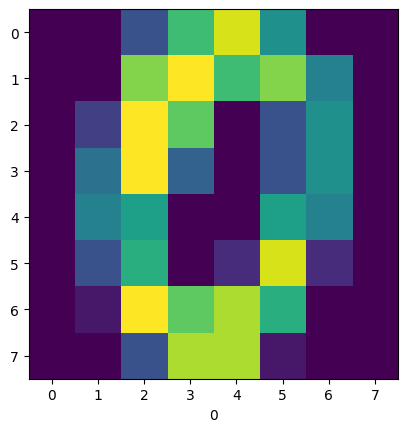

In [ ]:
pred1 = []
for i in range(Xtest.shape[0]):
  pred1.append(prediction(model,Xtest.iloc[i,:]))
plt.imshow(Xtest.iloc[5,:].to_numpy().reshape(8,8))
plt.xlabel(pred1[5])

In [ ]:
def Confusion_Matrix(true , pred):
  s = 0
  p = 0
  cm = np.zeros((data['target'].nunique(),data['target'].nunique()))
  for i in range(true.shape[0]):
    if true.to_numpy()[i] == pred[i]:
      cm[pred[i]][pred[i]] = cm[pred[i]][pred[i]] + 1
      s = s + 1
      p = p + 1
    else:
      cm[true.to_numpy()[i]][pred[i]] = cm[true.to_numpy()[i]][pred[i]] + 1
      p = p + 1
  return cm , (s*1.0)/p

[[55.  0.  0.  0.  0.  0.  1.  0.  1.  2.]
 [ 0. 53.  3.  1.  1.  1.  0.  0.  5.  4.]
 [ 1.  0. 40.  1.  0.  1.  0.  0.  4.  1.]
 [ 1.  3.  1. 34.  0.  0.  2.  1.  0.  5.]
 [ 1.  2.  0.  0. 55.  0.  1.  4.  1.  0.]
 [ 2.  0.  0.  0.  2. 40.  0.  0.  5.  1.]
 [ 0.  0.  0.  0.  2.  0. 52.  0.  0.  0.]
 [ 0.  1.  0.  0.  1.  1.  0. 48.  0.  2.]
 [ 0.  2.  0.  0.  0.  2.  0.  1. 43.  2.]
 [ 0.  1.  1.  1.  1.  0.  0.  4.  0. 38.]]
Accuracy 84.97217068645641%


Text(0.5, 25.722222222222214, 'Predicted Labels')

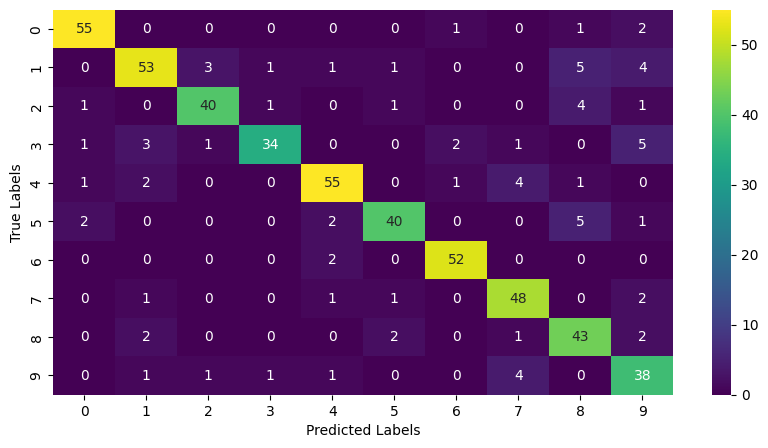

In [ ]:
import seaborn as sns
plt.figure(figsize = (10,5))
cnfm , accuracy = Confusion_Matrix(Ytest,pred1)
print(cnfm)
print(f'Accuracy {accuracy * 100}%')
sns.heatmap(cnfm,annot = True ,cmap = 'viridis')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

# I will use Shannon Entropy and Information Gain to build my model

Shannon Entropy = $ - ∑_i P_i log_2(P_i)$ where $P_i$ is probability of a i-th target in dataset

In [ ]:
def shanon_entropy(dataframe):
  sum = dataframe['target'].value_counts().values.sum()
  s = 0.0
  for i in dataframe['target'].value_counts().keys():
    s = s - (dataframe['target'].value_counts()[i]/sum)*np.log2((dataframe['target'].value_counts()[i]/sum))
  return s

In [ ]:
def split(n,a):
    dict = {}
    for i in n :
        entropy_L = shanon_entropy(a[a.iloc[:,0]<= i])
        size_L =  a[a.iloc[:,0]<= i].shape[0]
        entropy_R = shanon_entropy(a[a.iloc[:,0] > i])
        size_R =  a[a.iloc[:,0] > i].shape[0]
        dict[i] = (size_L/a.shape[0])*entropy_L + (size_R/a.shape[0])*entropy_R
    return dict

In [ ]:
def gain(entropy,d,b):
    actual = shanon_entropy(d)
    info_gain = []
    for i in entropy.values():
        info_gain.append(actual - i)
    return (np.max(info_gain),b[np.argmax(info_gain)])     # Returning the maximum information Gain and Best split value

In [ ]:
def finding_threshold(col,data):
    a = data[[col,'target']].sort_values(by = col).reset_index(drop = True)
    b = []
    for i in range(1,a.shape[0]):
        if a.iloc[i,1] != a.iloc[i-1,1]:
            b.append((a.iloc[i,0] + a.iloc[i-1,0])/2.0)       # Storing the mid - points of transition points
    b = np.unique(b)    # b can have multiple repeated values but it doesn't matter because splitting considers all of them in single run
    if b.size == 0 :
        return None,None
    split_entropy = split(b,a)
    return gain(split_entropy,data,b)

In [ ]:
def build_model(data,thres_info_gain,depth):
    tree = {}
    best_feature = None
    best_split = 0

    entropy = shanon_entropy(data)
    info_gain = 0

    for i in data.columns:
        if i != 'target':
            temp , t = finding_threshold(i,data)
            if temp is None:
                continue              # If a particular feature is useless , it is skipping that feature to next iteration
            if temp > info_gain:
                info_gain = temp
                best_feature = i
                best_split = t

    if best_feature is None:     #If the loop skipped through all Features for a totally pure(target constant) Dataframe
      return data['target'].mode().values[0]

    print(f"Depth {depth} Best Feature : {best_feature} Information Gain : {round(info_gain,3)} Shanon Entropy : {round(entropy,3)}")
    # Setting some Stopping Conditions to stop large number of ierations or Overfitting

    if info_gain < thres_info_gain :
        return data['target'].mode().values[0]

    if entropy == 0:
        return data['target'].mode().values[0]

    tree['Best Feature'] = best_feature
    tree['Threshold'] = best_split
     # Including this Left and Right within the Dictionary (not the recusion calls) was obtained from searches as I couldn't figure it out myself
    tree['left'] = build_model(data[data[best_feature] <= best_split],thres_info_gain,depth + 1)
    tree['right'] = build_model(data[data[best_feature] > best_split],thres_info_gain,depth + 1)

    return tree


In [ ]:
def prediction(tree,sample):
    if isinstance(tree,(np.floating,np.integer)):
        return tree
    if sample[tree['Best Feature']] > tree['Threshold']:
        return prediction(tree['right'],sample)
    else:
        return prediction(tree['left'],sample)

In [ ]:
model = build_model(Xtrain , thres_info_gain = 0.01 , depth = 0 )

Depth 0 Best Feature : pixel_5_2 Information Gain : 0.485 Shanon Entropy : 3.32
Depth 1 Best Feature : pixel_5_3 Information Gain : 0.462 Shanon Entropy : 2.856
Depth 2 Best Feature : pixel_3_2 Information Gain : 0.533 Shanon Entropy : 2.192
Depth 3 Best Feature : pixel_3_6 Information Gain : 0.488 Shanon Entropy : 1.217
Depth 4 Best Feature : pixel_7_7 Information Gain : 0.358 Shanon Entropy : 0.68
Depth 5 Best Feature : pixel_0_4 Information Gain : 0.148 Shanon Entropy : 0.218
Depth 6 Best Feature : pixel_2_2 Information Gain : 1.0 Shanon Entropy : 1.0
Depth 5 Best Feature : pixel_0_2 Information Gain : 0.971 Shanon Entropy : 1.522
Depth 6 Best Feature : pixel_0_4 Information Gain : 0.918 Shanon Entropy : 0.918
Depth 4 Best Feature : pixel_5_4 Information Gain : 0.677 Shanon Entropy : 0.949
Depth 5 Best Feature : pixel_0_2 Information Gain : 0.971 Shanon Entropy : 1.522
Depth 6 Best Feature : pixel_0_2 Information Gain : 0.918 Shanon Entropy : 0.918
Depth 3 Best Feature : pixel_2_5 I

In [ ]:
model

{'Best Feature': 'pixel_5_2',
 'Threshold': np.float64(7.0),
 'left': {'Best Feature': 'pixel_5_3',
  'Threshold': np.float64(3.0),
  'left': {'Best Feature': 'pixel_3_2',
   'Threshold': np.float64(5.0),
   'left': {'Best Feature': 'pixel_3_6',
    'Threshold': np.float64(1.0),
    'left': {'Best Feature': 'pixel_7_7',
     'Threshold': np.float64(0.0),
     'left': {'Best Feature': 'pixel_0_4',
      'Threshold': np.float64(8.0),
      'left': {'Best Feature': 'pixel_2_2',
       'Threshold': np.float64(9.0),
       'left': np.int64(3),
       'right': np.int64(9)},
      'right': np.int64(3)},
     'right': {'Best Feature': 'pixel_0_2',
      'Threshold': np.float64(6.0),
      'left': {'Best Feature': 'pixel_0_4',
       'Threshold': np.float64(3.0),
       'left': np.int64(1),
       'right': np.int64(9)},
      'right': np.int64(2)}},
    'right': {'Best Feature': 'pixel_5_4',
     'Threshold': np.float64(9.5),
     'left': np.int64(9),
     'right': {'Best Feature': 'pixel_0_2',

 # Root Node is pixel_5_2 and Shanon Entropy : 3.32

Text(0.5, 0, '0')

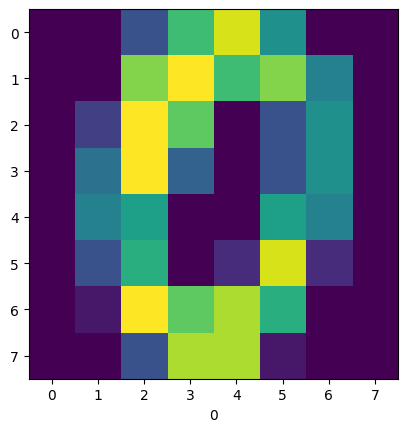

In [ ]:
pred2 = []
for i in range(Xtest.shape[0]):
  pred2.append(prediction(model,Xtest.iloc[i,:]))
plt.imshow(Xtest.iloc[5,:].to_numpy().reshape(8,8))
plt.xlabel(pred2[5])

[[55.  0.  0.  0.  0.  0.  1.  0.  1.  2.]
 [ 0. 53.  3.  1.  1.  1.  0.  0.  5.  4.]
 [ 1.  0. 40.  1.  0.  1.  0.  0.  4.  1.]
 [ 1.  3.  1. 34.  0.  0.  2.  1.  0.  5.]
 [ 1.  2.  0.  0. 55.  0.  1.  4.  1.  0.]
 [ 2.  0.  0.  0.  2. 40.  0.  0.  5.  1.]
 [ 0.  0.  0.  0.  2.  0. 52.  0.  0.  0.]
 [ 0.  1.  0.  0.  1.  1.  0. 48.  0.  2.]
 [ 0.  2.  0.  0.  0.  2.  0.  1. 43.  2.]
 [ 0.  1.  1.  1.  1.  0.  0.  4.  0. 38.]]
Accuracy 84.97217068645641%


Text(95.72222222222221, 0.5, 'Predicted Labels')

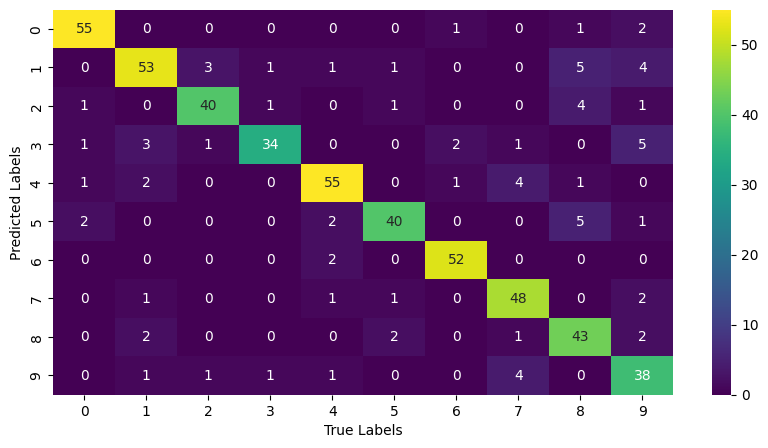

In [ ]:
import seaborn as sns
plt.figure(figsize = (10,5))
cnfm , accuracy = Confusion_Matrix(Ytest,pred2)
print(cnfm)
print(f'Accuracy {accuracy * 100}%')
sns.heatmap(cnfm,annot = True ,cmap = 'viridis')
plt.xlabel('True Labels')
plt.ylabel('Predicted Labels')

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score

In [ ]:
model1 = DecisionTreeClassifier(criterion = 'gini' , min_impurity_decrease = 0.01) # Minimum impurity decrease is basically thresh_info_gain

In [ ]:
model1.fit(Xtrain.iloc[:,:-1],Ytrain)
y = model1.predict(Xtest)

Accuracy is 78.10760667903524%


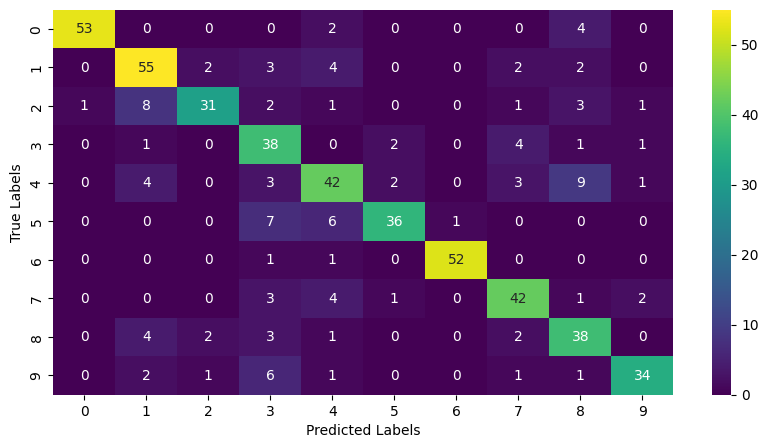

In [ ]:
plt.figure(figsize = (10,5))
cm = confusion_matrix(Ytest,y)
sns.heatmap(cm,annot = True ,cmap = 'viridis')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
print(f'Accuracy is {accuracy_score(Ytest.to_numpy(),y)*100}%')

In [ ]:
model2 = DecisionTreeClassifier(criterion = 'entropy' , min_impurity_decrease = 0.01)
model2.fit(Xtrain.iloc[:,:-1],Ytrain)
y1 = model2.predict(Xtest)
cm = confusion_matrix(Ytest,y1)

Accuracy is 83.6734693877551%


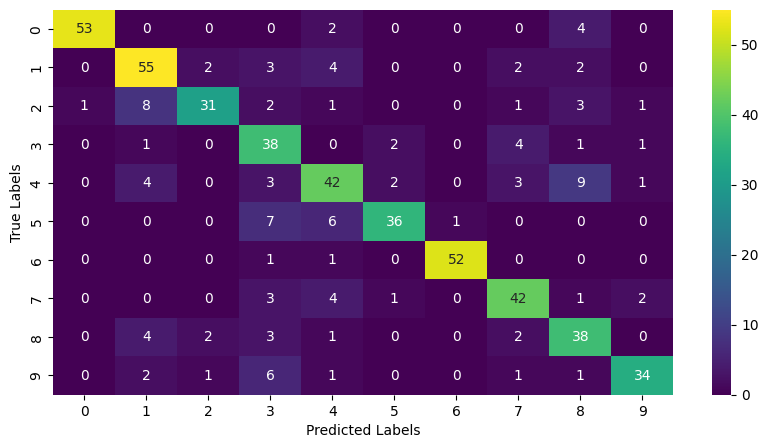

In [ ]:
plt.figure(figsize = (10,5))
sns.heatmap(cm,annot = True ,cmap = 'viridis')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
print(f'Accuracy is {accuracy_score(Ytest.to_numpy(),y1)*100}%')

In [ ]:
print(f"Root Node for Decision tree Model with Gini is {data.columns[model1.tree_.feature[0]]}")
print(f"Gini Impurity of Root Node for Decision tree Model with Gini is {round(model1.tree_.impurity[0],3)}")
print(f"Root Node for Decision tree Model with Entropy is {data.columns[model2.tree_.feature[0]]}")
print(f"Entropy of Root Node for Decision tree Model with Gini is {round(model2.tree_.impurity[0],3)}")

Root Node for Decision tree Model with Gini is pixel_2_5
Gini Impurity of Root Node for Decision tree Model with Gini is 0.9
Root Node for Decision tree Model with Entropy is pixel_5_2
Entropy of Root Node for Decision tree Model with Gini is 3.32


$$\Large
\begin{array}{|l|c|c|c|}
\hline
\textbf{Model} & \textbf{Root Feature} & \textbf{Root Impurity} & \textbf{Test Accuracy} \\
\hline
\text{Custom (Gini)} & \text{pixel_5_2} & 0.9 & 84.97\% \\
\hline
\text{Custom (Entropy)} & \text{pixel_5_2} & 3.32 & 84.97\% \\
\hline
\text{Sklearn (Gini)} & \text{pixel_2_5} & 0.9 & 78.10\% \\
\hline
\text{Sklearn (Entropy)} & \text{pixel_5_2} & 3.32 & 83.67\% \\
\hline
\end{array}$$

**Apparently , my custom model is performing better than Sklearn's Model . It can be due to** :     


1.   Threshold and Early Stopping Condition - Sklearn's min_impurity_decrease is not exactly equivalent to my info_gain_thres , hence model splits to higher depths resulting in slight overfitting which works well for the test dataset whereas Sklearn's Model stops much earlier.
2.   How information Gain is calculated from my formulas may not be exactly equivalent to Sklearn's Formula ( Don't know is this valid reason or not as i got this from Searches)



#**PROBLEM 4 (K Means Algorithm)**

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = load_iris(as_frame = True)
df = df['frame']
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


**Applying K Means Clustering with K = 3 on Unscaled Data**

In [ ]:
def eucleidian_distance(x1 , x2):
  return (np.sum((x1.values - x2.values)**2))**(0.5)


In [ ]:
def centroid(dic,data):
  s = {}

  for i in dic.keys():
    s[i] = data.iloc[dic[i]].mean()

  return s         # Returning centroid for each cluster

In [ ]:
def initialize(emp,k):
  for i in range(k):
    emp[i+1] = []
  return emp

In [ ]:
def random_initialization(data,k):
  np.random.seed(100)      # To get the same initial assignments , for reproducibility
  temp = {}
  temp = initialize(temp,k)
  for i in range(data.shape[0]):
    temp[np.random.choice(k)+1].append(i)         # randomly choosing a value from 0,1 or 2 and assigning it to a data point
  return temp

In [ ]:
def KMeans(k,data,tol):
  dict = {}
  count = 0
  #for i in range(k):
  #  dict[i+1] = [(i+4) + 50*i]    # Manual initialization which I used before
  dict = random_initialization(data , k)

  while True :

    centers = centroid(dict,data)

    dict = {}
    dict = initialize(dict,k)

    for i in range(data.shape[0]):   # For each sample , calculating distance from each centroid and assigning to nearest centroid
      distance = []
      for j in centers.keys():
        distance.append(eucleidian_distance(data.iloc[i],centers[j]))
      dict[np.argmin(distance) + 1].append(i)
    a = 0
    new_centroid = centroid(dict,data)
    for i in new_centroid.keys():
      a = a + np.sum((centers[i].values - new_centroid[i].values)**2)
    if a**(0.5) < tol and count > 0:
      return dict
    count = count + 1

In [ ]:
clusters = KMeans(3 , df.iloc[:,:-1],0.001)    # If this cell takes longer to execute , stop and re run this

In [ ]:
print(clusters[1])
print(clusters[2])
print(clusters[3])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
[50, 52, 77, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 115, 116, 117, 118, 120, 122, 124, 125, 128, 129, 130, 131, 132, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 147, 148]
[51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 114, 119, 121, 123, 126, 127, 133, 138, 142, 146, 149]


In [ ]:
def standard_scaler(x):
  return (x - x.mean())/np.sqrt(x.var())

In [ ]:
df1 = df.iloc[:,:-1].apply(standard_scaler,axis = 0)

In [ ]:
clusters1 = KMeans(3,df1,0.001)

In [ ]:
print(clusters1[1])
print(clusters1[2])
print(clusters1[3])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49]
[50, 51, 52, 54, 56, 58, 65, 70, 75, 76, 77, 85, 86, 100, 102, 103, 104, 105, 107, 108, 109, 110, 111, 112, 114, 115, 116, 117, 118, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 135, 136, 137, 138, 139, 140, 141, 143, 144, 145, 147, 148, 149]
[41, 53, 55, 57, 59, 60, 61, 62, 63, 64, 66, 67, 68, 69, 71, 72, 73, 74, 78, 79, 80, 81, 82, 83, 84, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 101, 106, 113, 119, 121, 134, 142, 146]


**Calculating the Inertia (Within-Cluster Sum of Squares)**\
$ ∑_{k=1}^K ∑_{{x_i} ϵ {C_k}}||x_i - μ_k||^2$

In [ ]:
def inertia(data,clust):

  c = centroid(clust,data)
  s = 0.0
  for i in clust.keys():
    for j in clust[i]:
      s = s + np.sum((data.iloc[j] - c[i])**2)

  return s

In [ ]:
print(f'Inertia without Feature Scaling : {inertia(df.iloc[:,:-1],clusters)}')
print(f'Inertia with feature Scaling : {inertia(df1.iloc[:,:-1],clusters1)}')

Inertia without Feature Scaling : 78.85566582597733
Inertia with feature Scaling : 120.87094895343634


**Calculating the Adjusted Rank Index(ARI)**

We have to generate all possible pair of points and let a be all the pairs whose labels are same and belong to same cluster whereas b are all pairs who labels are different and belongs to different clusters , so

Rank Index (RI) = $\frac{a+b}{^nC_2}$

Ε[RI] is basically the average Rank Index upon assigning 150 data points to 3 clusters completely at random multiple times .

Adjusted Rank index (ARI) = $\frac{RI - E[RI]}{max(RI) - E[RI]}$

It can be written as (obtained from web) :

$$ARI = \frac{n_{11} - \frac{(n_{11} + n_{10})(n_{11} + n_{01})}{N}}{\frac{(n_{11} + n_{10}) + (n_{11} + n_{01})}{2} - \frac{(n_{11} + n_{10})(n_{11} + n_{01})}{N}}$$

where
$n_{11}$: Number of pairs that are in the same cluster AND have the same label.
<br>$n_{10}$: Number of pairs in the same cluster but have different labels.
<br>$n_{01}$: Number of pairs in different clusters but have the same label.
<br>$N$: Total possible pairs $\binom{n}{2}$.

In [ ]:
def check(a,b,c,signal):
  flag = 0
  if signal == 0:     # Signal = 0 (for rank index) and 1(for adjusted rank index)
    for i in c.keys():
      if ((a in c[i]) and (b in c[i]) and (df.iloc[a].target) == (df.iloc[b].target)) :   # Same Cluster , Same Label
        return True
      elif ((a in c[i]) and (b not in c[i]) and (df.iloc[a].target) != (df.iloc[b].target)): # Different Cluster , Different Label
        return True
    return False
  else:
    for i in c.keys():
      if ((a in c[i]) and (b in c[i]) and (df.iloc[a].target) == (df.iloc[b].target)) :  # Same Cluster , Same Label
        flag = 1
      elif ((a in c[i]) and (b in c[i]) and (df.iloc[a].target) != (df.iloc[b].target)): # Same Cluster , Different Label
        flag = 2
      elif ((a in c[i]) and (b not in c[i]) and (df.iloc[a].target) == (df.iloc[b].target)): # Different Cluster , Same Label
        flag = 3
  return flag

In [ ]:
def Adjusted_Rank_Index(clust , data):
  true_positives = 0
  for i in range(data.shape[0]):
    for j in range(i+1,data.shape[0]):
      if check(i,j,clust,0):
        true_positives = true_positives  + 1

  rank_index = true_positives / ((data.shape[0]*(data.shape[0]-1))/2)

  same_cluster_same_label = 0
  same_cluster_diff_label = 0
  diff_cluster_same_label = 0

# ADJUSTED RANK INDEX

  for i in range(data.shape[0]):
    for j in range(i+1,data.shape[0]):
      if check(i,j,clust,1) == 1:
        same_cluster_same_label = same_cluster_same_label + 1
      elif check(i,j,clust,1) == 2:
        same_cluster_diff_label = same_cluster_diff_label + 1
      elif check(i,j,clust,1) == 3:
        diff_cluster_same_label = diff_cluster_same_label + 1

  #same_cluster_same_label = (same_cluster_same_label * (same_cluster_same_label-1))/2.0
  #same_cluster_diff_label = (same_cluster_diff_label * (same_cluster_diff_label-1))/2.0
  #diff_cluster_same_label = (diff_cluster_same_label * (diff_cluster_same_label-1))/2.0
  N = ((data.shape[0]*(data.shape[0]-1))/2)

  numerator = same_cluster_same_label - ((same_cluster_same_label + same_cluster_diff_label)*(same_cluster_same_label + diff_cluster_same_label))/N
  denominator = (((same_cluster_same_label + same_cluster_diff_label)+(same_cluster_same_label + diff_cluster_same_label))/2) - ((same_cluster_same_label + same_cluster_diff_label)*(same_cluster_same_label + diff_cluster_same_label))/N

  return (rank_index,numerator/denominator)


In [ ]:
print(f"The Rank index and Adjusted Rank Index for Unscaled data is {Adjusted_Rank_Index(clusters,df)}")
print(f"The Rank index and Adjusted Rank Index for Scaled data is {Adjusted_Rank_Index(clusters1,df1)}")

The Rank index and Adjusted Rank Index for Unscaled data is (0.8737360178970918, 0.7163421126838475)
The Rank index and Adjusted Rank Index for Scaled data is (0.8431319910514541, 0.645147003482001)


# We can observe that Inertia for Unscaled Data is lower than that of Scaled data


1.   Inertia without Feature Scaling : 78.85566582597733
2.   Inertia with Feature Scaling : 120.87094895343634

Inertia goes down when every feature is given same weightage .

# We can also see that Rank index and Adjusted Rank go down for Scaled Data.

1.   Rank Index and Adjusted Rank Index without Feature Scaling : 0.8737360178970918, 0.7163421126838475
2.   Rank Index and Adjusted Rank Index with Feature Scaling : 0.8431319910514541, 0.645147003482001

